# 🌍 Multi-Regional Housing Price Analysis
### California (USA) | Bangalore (India) | Bihar (India)

This project demonstrates a versatile machine learning pipeline capable of predicting housing prices across different geographical contexts and data formats.

# California Housing Price Prediction
This notebook explores the California Housing dataset, performs exploratory data analysis, and compares Linear Regression with a Random Forest Regressor.

--- Dataset Preview ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Generating Correlation Heatmap...



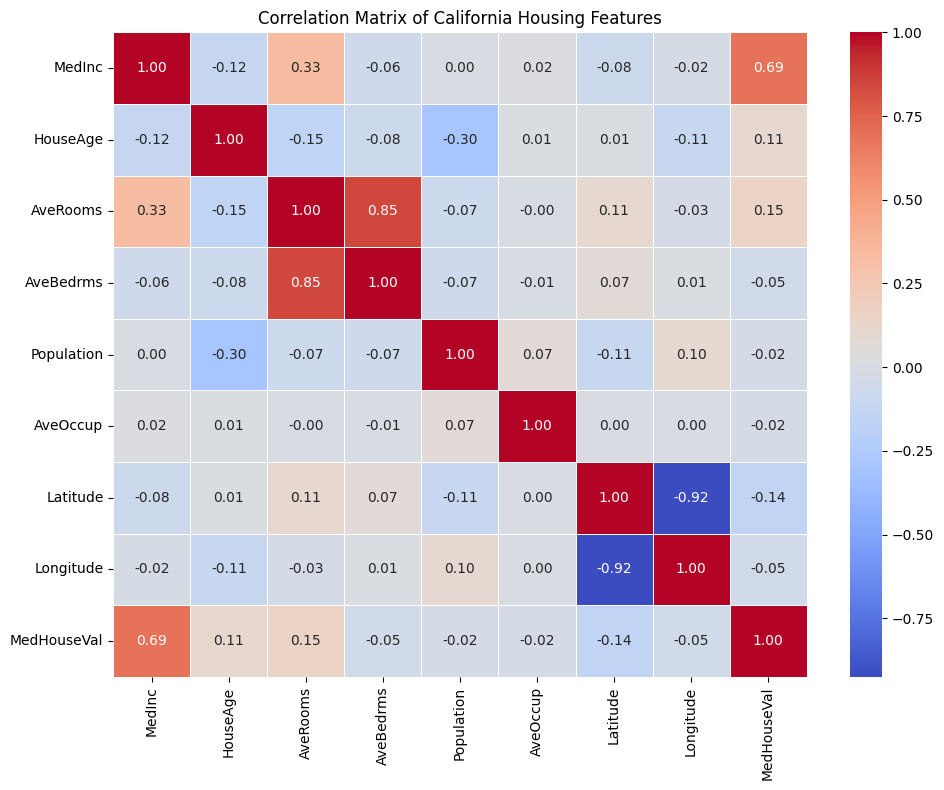

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# 1. Fetch the dataset
california = fetch_california_housing()

# 2. Convert it into a Pandas DataFrame for easier manipulation
housing_data = pd.DataFrame(california.data, columns=california.feature_names)

# Add the target variable (Median House Value in 100,000s) to the DataFrame
housing_data['MedHouseVal'] = california.target

# 3. Display a quick preview
print("--- Dataset Preview ---")
print(housing_data.head())
print("\nGenerating Correlation Heatmap...\n")

# 4. Calculate the Correlation Matrix
correlation_matrix = housing_data.corr()

# 5. Visualize the matrix using a Seaborn Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of California Housing Features")
plt.tight_layout()
plt.show()

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Define Features (X) and Target (y)
X = housing_data.drop('MedHouseVal', axis=1)
y = housing_data['MedHouseVal']

# 2. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# 4. Make predictions on the unseen test data
predictions = lin_reg.predict(X_test)

# 5. Evaluate the model
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("--- Baseline Linear Regression Performance ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

--- Baseline Linear Regression Performance ---
Mean Squared Error (MSE): 0.5559
R-squared (R2) Score: 0.5758


In [3]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize the Random Forest Regressor
# n_estimators=100 means we are building 100 decision trees
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the new model on the existing training data
rf_reg.fit(X_train, y_train)

# 3. Make predictions on the unseen test data
rf_predictions = rf_reg.predict(X_test)

# 4. Evaluate the upgraded model
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("--- Random Forest Regression Performance ---")
print(f"Mean Squared Error (MSE): {rf_mse:.4f}")
print(f"R-squared (R2) Score: {rf_r2:.4f}")

--- Random Forest Regression Performance ---
Mean Squared Error (MSE): 0.2554
R-squared (R2) Score: 0.8051


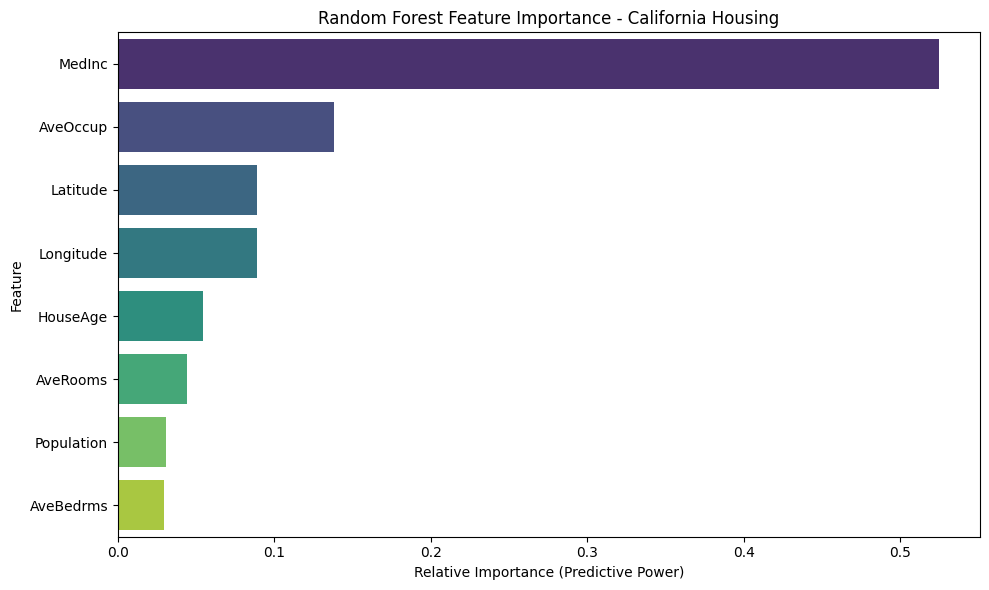

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extract the mathematical importances from the trained forest
importances = rf_reg.feature_importances_
feature_names = X.columns

# 2. Create a DataFrame and sort them from most to least important
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Visualize the rankings with a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Random Forest Feature Importance - California Housing')
plt.xlabel('Relative Importance (Predictive Power)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Final Summary and Conclusion

### Model Performance
- **Baseline Linear Regression**: MSE: 0.5559, R²: 0.5758
- **Random Forest Regressor**: MSE: 0.2554, R²: 0.8051

### Key Findings
- Moving from a linear model to an ensemble method (Random Forest) significantly improved the predictive accuracy, capturing about 80% of the variance in housing prices.
- **Median Income (MedInc)** was by far the strongest predictor of house values.
- Geographical location (Latitude/Longitude) and the average occupancy also played significant roles in the model's decisions.

## Adapting for India: Bangalore Housing Example

To move this project to India, we typically use the **Bangalore House Price Dataset**. This requires a few changes because the features (columns) are different from the California dataset.

In [6]:
import pandas as pd

# Note: You would typically download 'Bengaluru_House_Data.csv' from Kaggle.
# For this demonstration, we'll outline the structure you would use.

try:
    # Path to your Indian housing dataset
    india_housing = pd.read_csv('Bengaluru_House_Data.csv')

    # 1. Basic Cleaning (Indian datasets often have mixed units or 'ready-to-move' strings)
    print("Initial Columns:", india_housing.columns)

    # 2. Convert 'total_sqft' to numeric (handling ranges like '2100 - 2850')
    def convert_sqft_to_num(x):
        tokens = str(x).split('-')
        if len(tokens) == 2:
            return (float(tokens[0]) + float(tokens[1])) / 2
        try:
            return float(x)
        except:
            return None

    if 'total_sqft' in india_housing.columns:
        india_housing['total_sqft'] = india_housing['total_sqft'].apply(convert_sqft_to_num)

    display(india_housing.head())
except FileNotFoundError:
    print("Dataset file not found. Please upload 'Bengaluru_House_Data.csv' to the Colab files tab.")

Dataset file not found. Please upload 'Bengaluru_House_Data.csv' to the Colab files tab.


### Differences to Note:
- **Location**: In India, we often use 'Area Name' or 'City' instead of Latitude/Longitude.
- **Features**: Features like 'BHK' (Bedroom, Hall, Kitchen) and 'Bath' are more common than 'AveRooms'.
- **Target**: The price is usually in 'Lakhs' or 'Crores' (INR) rather than 100k USD.

## 🚀 Portability Checklist: California vs. India

To finalize your project for both locations, ensure you follow these steps when switching datasets:

1.  **Data Loading**: Replace `fetch_california_housing()` with `pd.read_csv('your_india_data.csv')`.
2.  **Feature Engineering**:
    - **California**: Focuses on `MedInc` and `AveOccup`.
    - **India**: Requires cleaning strings in `total_sqft` and handling categorical data like `location` or `area_type` using One-Hot Encoding.
3.  **Units & Scale**:
    - **California**: Prices are in 100k USD.
    - **India**: Prices are usually in Lakhs (₹1,00,000) or Crores (₹1,00,00,000).
4.  **Model Retraining**: Always re-run the `train_test_split` and `fit()` methods after changing the input data to ensure the Random Forest learns the specific patterns of the Indian market.

## 🏡 Expanding to Bihar: Regional Data Analysis

Real estate in Bihar (e.g., Patna, Muzaffarpur) often uses traditional land units like **Katha** or **Dhur**. To make our model work here, we need to convert these into a standard square footage format.

In [7]:
import pandas as pd

def convert_bihar_units_to_sqft(value, unit_type):
    """
    Helper to convert traditional Bihar land units to Sq. Ft.
    Approximate conversion: 1 Katha ≈ 1361 Sq. Ft.
    """
    conversions = {
        'katha': 1361.25,
        'dhur': 68.06,
        'sqft': 1.0
    }
    return value * conversions.get(unit_type.lower(), 1.0)

try:
    # Placeholder for Bihar Housing Dataset (e.g., Patna_Real_Estate.csv)
    bihar_housing = pd.read_csv('Bihar_Housing_Data.csv')

    # Example: Converting 'area_in_katha' to square feet
    if 'area_katha' in bihar_housing.columns:
        bihar_housing['total_sqft'] = bihar_housing['area_katha'] * 1361.25

    print("Bihar Dataset Loaded Successfully")
    display(bihar_housing.head())
except FileNotFoundError:
    print("Bihar dataset not found. Upload 'Bihar_Housing_Data.csv' to analyze regional prices.")

Bihar dataset not found. Upload 'Bihar_Housing_Data.csv' to analyze regional prices.


### Regional Insights for Bihar:
- **Pricing**: Often quoted per 'Katha' in residential plots.
- **Amenities**: Proximity to the Ganga river or major highways (like NH-30) are key price drivers.
- **Market Type**: High demand for independent houses and plots compared to high-rise apartments.

## 🛠️ How to use this Notebook for GitHub Users

1. **Standard Analysis**: Run the first 5 cells to see a complete Random Forest pipeline using the built-in California dataset.
2. **Custom Indian Data**: Upload `Bengaluru_House_Data.csv` to the files tab and run the **India** section.
3. **Traditional Regional Data**: Upload `Bihar_Housing_Data.csv` and run the **Bihar** section to see how we handle traditional units like 'Katha'.

### Requirements
- `pandas`
- `seaborn`
- `scikit-learn`